Libraries and helper functions:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter
from helpers.adaptMultichannel import adaptMultichannel
from helpers.adaptSMC import adaptSHat, adaptPHat
from scipy.signal import butter, sosfilt

2


Simulation:

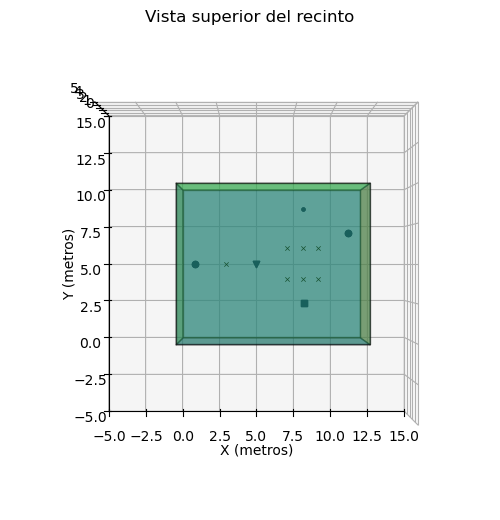

In [2]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 5, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 3.5])
room.add_source([5, 5, 2.5])
room.add_source([8, 8.5, 2.5])
room.add_source([11, 7, 1.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [3]:
nReferenceMics = 1
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (1, 152)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 261)


Algorithm:

/home/juana/miniconda3/envs/room-opt-complex/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


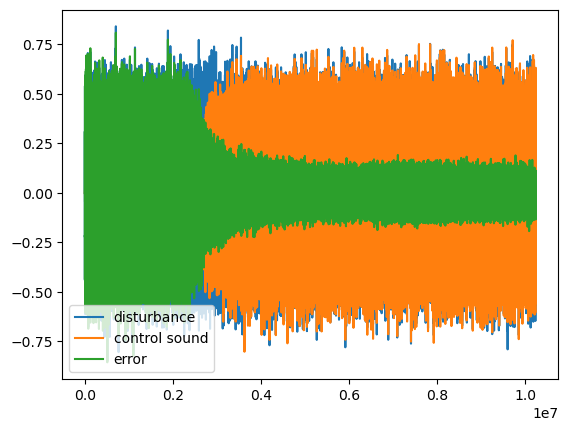

Noise reduction:  [-13.00055844 -12.38739037 -11.05718666 -12.7510272   -9.76690901
  -9.51184066]


NameError: name 'sResponse' is not defined

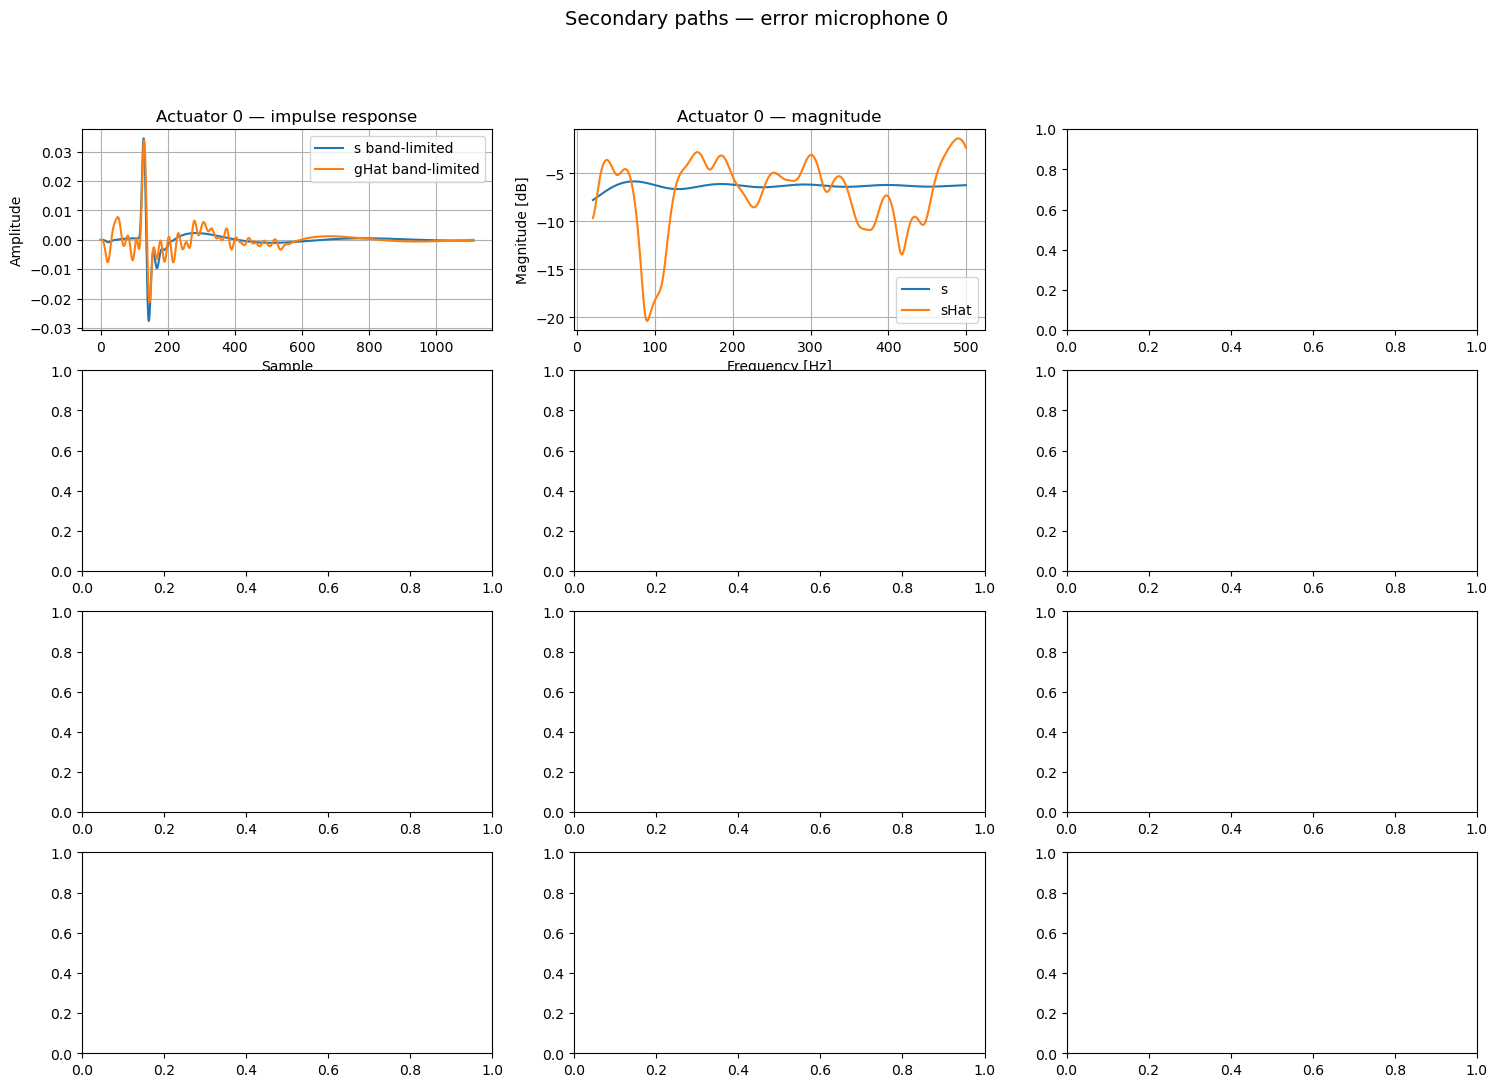

In [ ]:
# Disturbance
blocklength = 1024
nBlocks = 10000
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
whiteNoise = np.random.randn(N)
sos = butter(
    6,
    [20, 500],
    btype="bandpass",
    fs=fs,
    output="sos"
)
x = sosfilt(sos, whiteNoise)
x /= np.std(x) + 1e-12

# Adaptive filter matrix definition
nTaps = 512
wFilter = np.zeros((nActuators, nReferenceMics, nTaps))
for nActuator in range(nActuators):
    wFilter[nActuator, 0, nActuator] = 0.01
mu = 0.01

# Primary paths model filter matrix definition
pHat = np.zeros((nErrorMics, nReferenceMics, nTaps))    # Has a different dimension from the real P(Z),
                                                        # since it has to be modelled from the reference signals,
                                                        # while the real P(Z) acts directly on the source.
muP = 0.0001

# Secondary paths model filter matrix definition
gHat = np.zeros((nErrorMics, nActuators, nTaps))
muS = 0.001                

# Spectrums and buffers for online convolution
Mr = referencePaths.shape[1]
Nr = blocklength + Mr - 1
rSpectrum = np.fft.rfft(referencePaths, n=Nr, axis=-1)
rBuffer = np.zeros(Mr - 1)

Mp = primaryPaths.shape[1]
Np = blocklength + Mp - 1
pSpectrum = np.fft.rfft(primaryPaths, n=Np, axis=-1)
pBuffer = np.zeros(Mp - 1)

Mg = secondaryPaths.shape[2]
Ng = blocklength + Mg - 1
gSpectrum = np.fft.rfft(secondaryPaths, n=Ng, axis=-1)
gBuffer = np.zeros((nActuators, Mg - 1))

Mw = nTaps
Nw = blocklength + Mw - 1
wBuffer = np.zeros((nReferenceMics, Mw - 1))

MpHat = pHat.shape[2]
NpHat = blocklength + MpHat - 1
pHatBuffer = np.zeros((nReferenceMics, MpHat - 1))

MgHat = gHat.shape[2]
NgHat = blocklength + MgHat - 1
gHatFXBuffer = np.zeros((nReferenceMics, MgHat - 1))    # Buffer por generating the filtered reference
gHatSMCBuffer = np.zeros((nActuators, MgHat - 1))       # Buffer for adapting the secondary path

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))
mE = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Reference signals (simulation)
    xSignalExt = np.concatenate([rBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Nr)
    rSignalsSpectrum = rSpectrum * xSpectrum
    rSignalsExt = np.fft.irfft(rSignalsSpectrum, n=Nr, axis=-1)
    rSignals = rSignalsExt[:, Mr - 1:]
    rBuffer = xSignalExt[-(Mr - 1):]
        
    # Disturbance signals (simulation)
    xSignalExt = np.concatenate([pBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Np)
    dSignalsSpectrum = pSpectrum * xSpectrum
    dSignalsExt = np.fft.irfft(dSignalsSpectrum, n=Np, axis=-1)
    dSignals = dSignalsExt[:, Mp - 1:]
    pBuffer = xSignalExt[-(Mp - 1):]
        
    # Actuators signals
    rSignalsExt = np.concatenate([wBuffer, rSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=Nw, axis=-1)
    wSpectrum = np.fft.rfft(wFilter, n=Nw, axis=-1)
    aSignalsSpectrum = np.einsum('mkf,kf->mf', wSpectrum, rSignalsSpectrum)
    aSignalsExt = np.fft.irfft(aSignalsSpectrum, n=Nw, axis=-1)
    aSignals = aSignalsExt[:, Mw - 1:]
    wBuffer = rSignalsExt[:, -(Mw - 1):]        
    
    # Control and Errors signals (simulation)
    aSignalsExt = np.concatenate([gBuffer, aSignals], axis=1)
    aSignalsSpectrum = np.fft.rfft(aSignalsExt, n=Ng, axis=-1)
    cSignalsSpectrum = np.einsum('emf,mf->ef', gSpectrum, aSignalsSpectrum)
    cSignalsExt = np.fft.irfft(cSignalsSpectrum, n=Ng, axis=-1)
    cSignals = cSignalsExt[:, Mg - 1:]
    gBuffer = aSignalsExt[:, -(Mg - 1):]

    eSignals = dSignals - cSignals
    
    ################## Algorithm ##################

    # Compute the filtered reference matrix
    rSignalsExt = np.concatenate([gHatFXBuffer, rSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=NgHat, axis=-1)
    gHatSpectrum = np.fft.rfft(gHat, n=NgHat, axis=-1)   
    frSignalsSpectrum = np.einsum('emf,kf->emkf', gHatSpectrum, rSignalsSpectrum)   # Extra time could be saved here, since this fft is calculated inside adaptMultichannel
    frSignalsExt = np.fft.irfft(frSignalsSpectrum, n=NgHat, axis=-1)
    frSignals = frSignalsExt[..., MgHat - 1:]
    gHatFXBuffer = rSignalsExt[:, -(MgHat - 1):]

    # LMS algorithm
    wFilter = adaptMultichannel(
        frSignals,
        eSignals,
        nTaps,
        blocklength,
        wFilter,
        mu
    )

    # Filter the references by pHat
    rSignalsExt = np.concatenate([pHatBuffer, rSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=NpHat, axis=-1)
    pHatSpectrum = np.fft.rfft(pHat, n=NpHat, axis=-1)
    pHatSignalsSpectrum = np.einsum('ekf,kf->ef', pHatSpectrum, rSignalsSpectrum)
    pHatSignalsExt = np.fft.irfft(pHatSignalsSpectrum, n=NpHat, axis=-1)
    pHatSignals = pHatSignalsExt[:, MpHat - 1:]
    pHatBuffer = rSignalsExt[:, -(MpHat - 1):] 

    # Filter the actuators signals by gHat
    aSignalsExt = np.concatenate([gHatSMCBuffer, aSignals], axis=1)   
    aSignalsSpectrum = np.fft.rfft(aSignalsExt, n=NgHat, axis=-1)
    gHatSpectrum = np.fft.rfft(gHat, n=NgHat, axis=-1)
    gHatSignalsSpectrum = np.einsum('emf,mf->ef', gHatSpectrum, aSignalsSpectrum)
    gHatSignalsExt = np.fft.irfft(gHatSignalsSpectrum, n=NgHat, axis=-1)
    gHatSignals = gHatSignalsExt[:, MgHat - 1:]
    gHatSMCBuffer = aSignalsExt[:, -(MgHat - 1):] 

    # Compute the modelling error
    eHatSignals = pHatSignals - gHatSignals
    modelingErrorSignals = eSignals - eHatSignals

    # Adapt pHat
    pHat = adaptPHat(
        rSignals,
        modelingErrorSignals,
        nTaps,
        blocklength,
        pHat,
        muP
    )

    # Adapt sHat
    gHat = adaptSHat(
        aSignals,
        modelingErrorSignals,
        nTaps,
        blocklength,
        gHat,
        muS
    )
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    xRef[:, start:end] = rSignals
    d[:, start:end] = dSignals
    u[:, start:end] = aSignals
    y[:, start:end] = cSignals
    e[:, start:end] = eSignals
    mE[:, start:end] = modelingErrorSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
#plt.plot(mE[0], label="modelling error")
plt.legend()
plt.show()

################## Post-algorithm analysis ##################

# 1. Noise reduction
steadySamples = 500 * blocklength

errorMse = np.mean(
    e[:, -steadySamples:] ** 2,
    axis=1
)

disturbanceMse = np.mean(
    d[:, -steadySamples:] ** 2,
    axis=1
)

reductionDb = 10 * np.log10(
    errorMse / disturbanceMse
)

print("Noise reduction: ", reductionDb)

# 2. Misalignment
from scipy.signal import freqz, sosfilt

lowFrequency = 20
highFrequency = 500
nFrequencies = 8192
epsilon = 1e-12

# Debe ser el mismo filtro usado para generar el ruido band-limited.
# Por ejemplo:
# sos = butter(
#     6,
#     [lowFrequency, highFrequency],
#     btype="bandpass",
#     fs=fs,
#     output="sos"
# )

for nError in range(nErrorMics):

    fig, axes = plt.subplots(
        nActuators,
        3,
        figsize=(18, 3 * nActuators),
        squeeze=False
    )

    fig.suptitle(
        f"Secondary paths — error microphone {nError}",
        fontsize=14
    )

    for nActuator in range(nActuators):

        gReal = secondaryPaths[nError, nActuator]
        gEstimated = gHat[nError, nActuator]

        # Igualar longitudes
        nCommonTaps = max(len(gReal), len(gEstimated))

        gRealPadded = np.pad(
            gReal,
            (0, nCommonTaps - len(gReal))
        )

        gEstimatedPadded = np.pad(
            gEstimated,
            (0, nCommonTaps - len(gEstimated))
        )

        # -------------------------------------------------
        # Respuestas impulsivas limitadas a la banda elegida
        # -------------------------------------------------

        # Agregamos ceros para observar la cola del pasa banda
        extraSamples = int(fs / lowFrequency)

        gRealExtended = np.pad(
            gRealPadded,
            (0, extraSamples)
        )

        gEstimatedExtended = np.pad(
            gEstimatedPadded,
            (0, extraSamples)
        )

        # Mismo filtro para ambas plantas
        gRealBand = sosfilt(sos, gRealExtended)
        gEstimatedBand = sosfilt(sos, gEstimatedExtended)

        axes[nActuator, 0].plot(
            gRealBand,
            label="s band-limited"
        )

        axes[nActuator, 0].plot(
            gEstimatedBand,
            label="gHat band-limited"
        )

        axes[nActuator, 0].set_title(
            f"Actuator {nActuator} — impulse response"
        )
        axes[nActuator, 0].set_xlabel("Sample")
        axes[nActuator, 0].set_ylabel("Amplitude")
        axes[nActuator, 0].grid()
        axes[nActuator, 0].legend()

        # ----------------------
        # Respuesta en frecuencia
        # ----------------------

        frequencies, gResponse = freqz(
            gRealPadded,
            worN=nFrequencies,
            fs=fs
        )

        _, gHatResponse = freqz(
            gEstimatedPadded,
            worN=nFrequencies,
            fs=fs
        )

        bandMask = (
            (frequencies >= lowFrequency)
            & (frequencies <= highFrequency)
        )

        # Magnitud
        gMagnitudeDb = 20 * np.log10(
            np.abs(gResponse) + epsilon
        )

        gHatMagnitudeDb = 20 * np.log10(
            np.abs(gHatResponse) + epsilon
        )

        axes[nActuator, 1].plot(
            frequencies[bandMask],
            gMagnitudeDb[bandMask],
            label="s"
        )

        axes[nActuator, 1].plot(
            frequencies[bandMask],
            gHatMagnitudeDb[bandMask],
            label="sHat"
        )

        axes[nActuator, 1].set_title(
            f"Actuator {nActuator} — magnitude"
        )
        axes[nActuator, 1].set_xlabel("Frequency [Hz]")
        axes[nActuator, 1].set_ylabel("Magnitude [dB]")
        axes[nActuator, 1].grid()
        axes[nActuator, 1].legend()

        # Error relativo de fase
        phaseError = np.angle(
            gHatResponse * np.conj(gResponse),
            deg=True
        )

        axes[nActuator, 2].plot(
            frequencies[bandMask],
            phaseError[bandMask]
        )

        axes[nActuator, 2].axhline(
            0,
            linestyle="--"
        )

        axes[nActuator, 2].set_ylim(-180, 180)
        axes[nActuator, 2].set_title(
            f"Actuator {nActuator} — phase error"
        )
        axes[nActuator, 2].set_xlabel("Frequency [Hz]")
        axes[nActuator, 2].set_ylabel(
            "∠sHat − ∠s [°]"
        )
        axes[nActuator, 2].grid()

    plt.tight_layout()
    plt.show()


